In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
df = pd.read_csv("olympics_dataset.csv")

In [57]:
df.shape

(1500, 10)

In [58]:
df.head()

,Year,Season,City,Sport,Event,Athlete,Gender,Country,Medal,Age
0,2008,Summer,London,Badminton,Event_4,Caeleb Dressel,Male,Jamaica,Silver,20
1,2020,Summer,Rio,Gymnastics,Event_20,Sushil Kumar,Female,USA,Gold,24
2,2020,Summer,Rio,Swimming,Event_8,Mary Kom,Female,Australia,Gold,35
3,2020,Summer,London,Swimming,Event_10,Yuzuru Hanyu,Female,Australia,Gold,32
4,2008,Summer,Tokyo,Wrestling,Event_11,Caeleb Dressel,Female,Jamaica,Silver,22


In [59]:
df.tail()

,Year,Season,City,Sport,Event,Athlete,Gender,Country,Medal,Age
1495,2012,Summer,Tokyo,Gymnastics,Event_8,Michael Phelps,Female,India,Gold,22
1496,2020,Summer,London,Badminton,Event_18,Mirabai Chanu,Male,Australia,Bronze,31
1497,2016,Summer,London,Athletics,Event_17,Wayde van Niekerk,Female,UK,Bronze,23
1498,2008,Summer,Beijing,Gymnastics,Event_10,Wayde van Niekerk,Male,India,Bronze,20
1499,2008,Summer,Rio,Boxing,Event_7,P V Sindhu,Female,India,Bronze,22


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Year     1500 non-null   int64
 1   Season   1500 non-null   str  
 2   City     1500 non-null   str  
 3   Sport    1500 non-null   str  
 4   Event    1500 non-null   str  
 5   Athlete  1500 non-null   str  
 6   Gender   1500 non-null   str  
 7   Country  1500 non-null   str  
 8   Medal    1500 non-null   str  
 9   Age      1500 non-null   int64
dtypes: int64(2), str(8)
memory usage: 117.3 KB


In [61]:
cat_cols = ['Season','City','Sport','Event','Gender','Country','Medal']

for col in cat_cols:
    df[col] = df[col].astype('category')

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   Year     1500 non-null   int64   
 1   Season   1500 non-null   category
 2   City     1500 non-null   category
 3   Sport    1500 non-null   category
 4   Event    1500 non-null   category
 5   Athlete  1500 non-null   str     
 6   Gender   1500 non-null   category
 7   Country  1500 non-null   category
 8   Medal    1500 non-null   category
 9   Age      1500 non-null   int64   
dtypes: category(7), int64(2), str(1)
memory usage: 45.9 KB


In [63]:
df.drop_duplicates(inplace=True)

In [64]:
df.isnull().sum()

Year       0
Season     0
City       0
Sport      0
Event      0
Athlete    0
Gender     0
Country    0
Medal      0
Age        0
dtype: int64

In [65]:
df.describe()

,Year,Age
count,1500.000000,1500.000000
mean,2014.181333,26.452667
std,4.512726,5.242717
min,2008.000000,18.000000
25%,2012.000000,22.000000
50%,2016.000000,26.000000
75%,2020.000000,31.000000
max,2020.000000,35.000000


In [66]:
df.columns

Index(['Year', 'Season', 'City', 'Sport', 'Event', 'Athlete', 'Gender',
       'Country', 'Medal', 'Age'],
      dtype='str')

In [67]:
df.dropna(inplace=True)

In [68]:
df.shape

(1500, 10)

<Axes: xlabel='Medal'>

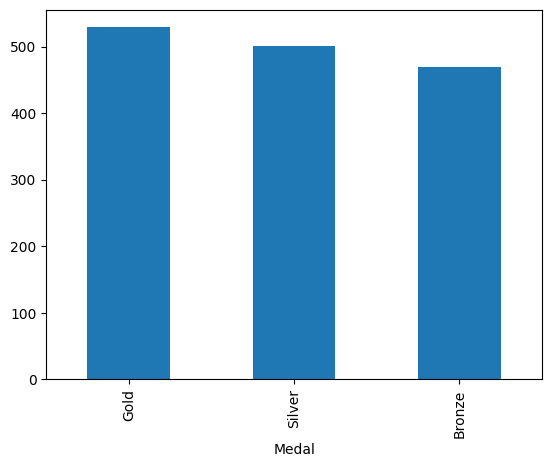

In [69]:
df['Medal'].value_counts().plot(kind='bar')

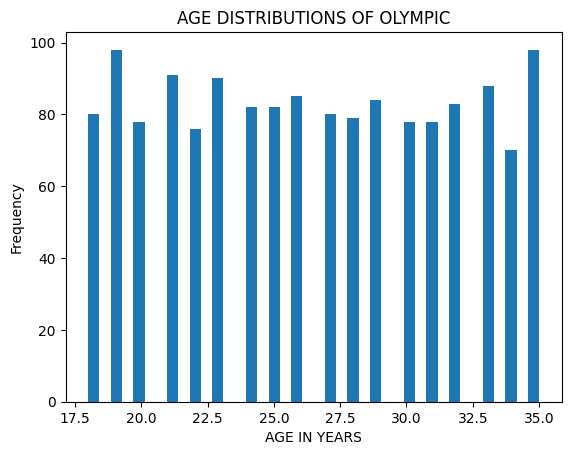

In [70]:
df['Age'].plot.hist(bins=40)
plt.title('AGE DISTRIBUTIONS OF OLYMPIC')
plt.xlabel('AGE IN YEARS')
plt.show()

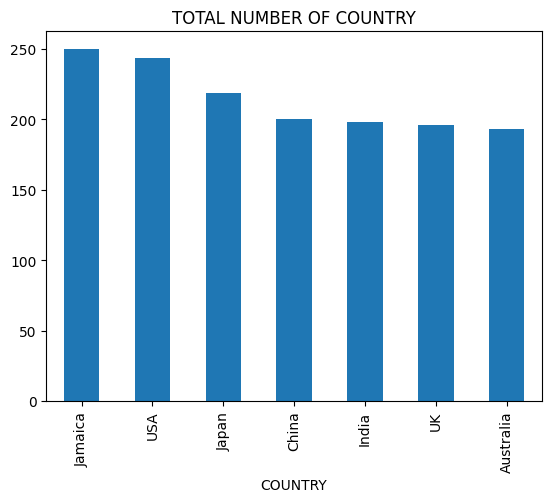

In [71]:
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title('TOTAL NUMBER OF COUNTRY')
plt.xlabel('COUNTRY')
plt.show()

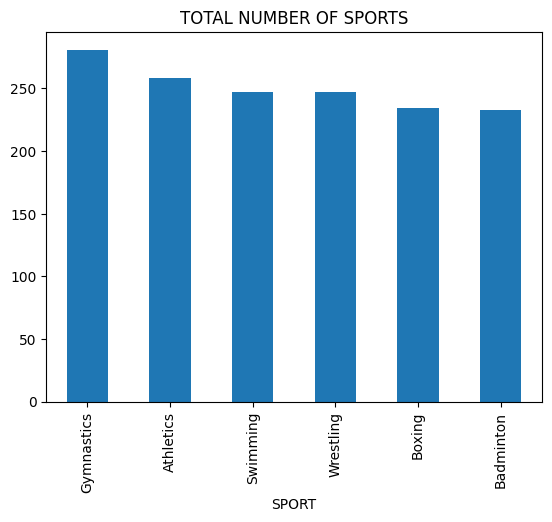

In [72]:
df['Sport'].value_counts().head(10).plot(kind='bar')
plt.title('TOTAL NUMBER OF SPORTS')
plt.xlabel('SPORT')
plt.show()

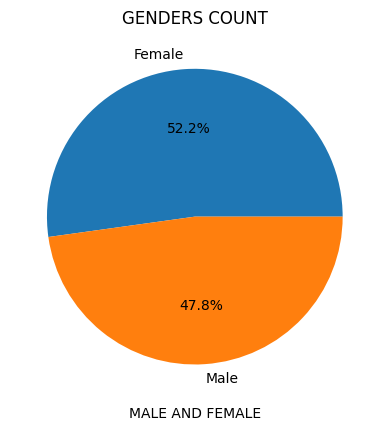

In [73]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('GENDERS COUNT')
plt.xlabel('MALE AND FEMALE')
plt.show()

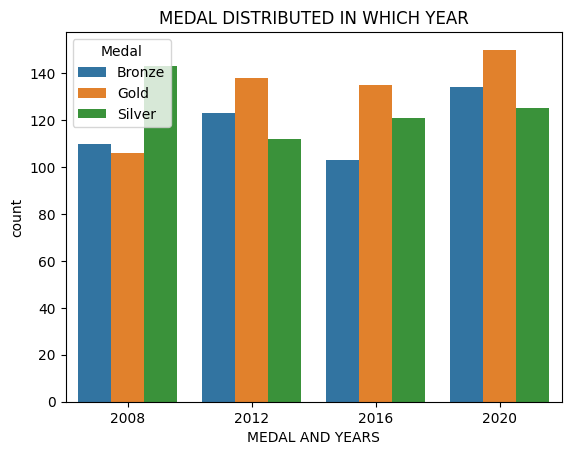

In [74]:
sns.countplot(data=df, x = 'Year', hue = 'Medal')
plt.title('MEDAL DISTRIBUTED IN WHICH YEAR')
plt.xlabel('MEDAL AND YEARS')
plt.show()

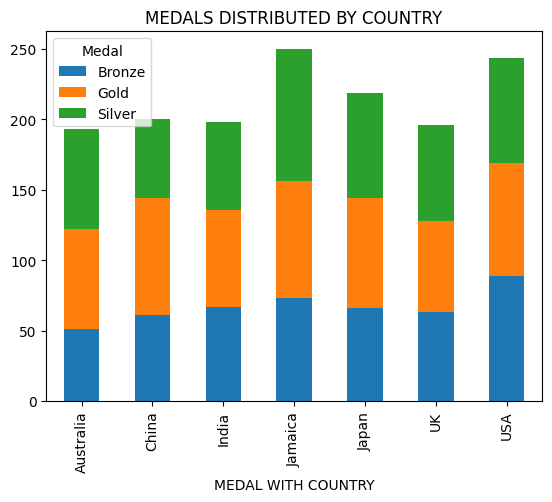

In [75]:
df.groupby(['Country','Medal']).size().unstack().plot(kind='bar', stacked=True)
plt.title('MEDALS DISTRIBUTED BY COUNTRY')
plt.xlabel('MEDAL WITH COUNTRY')
plt.show()

In [76]:
df['Athlete'].value_counts().head(10)

Athlete
P V Sindhu           136
Caeleb Dressel       134
Wayde van Niekerk    134
Sushil Kumar         133
Neeraj Chopra        125
Mirabai Chanu        124
Simone Biles         123
Serena Williams      122
Usain Bolt           120
Michael Phelps       120
Name: count, dtype: int64

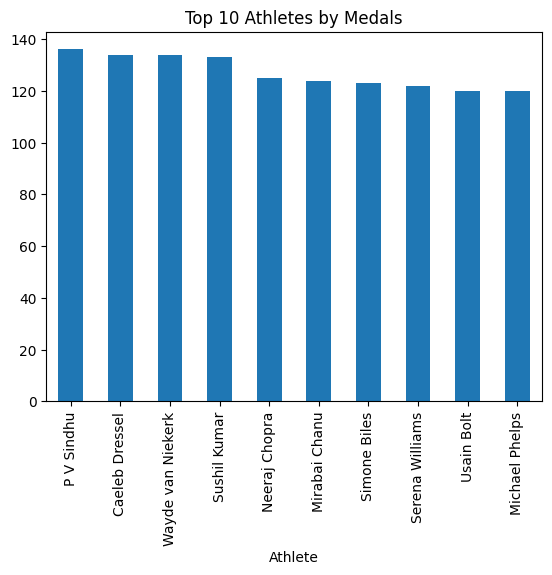

In [77]:
df['Athlete'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Athletes by Medals")
plt.show()

In [78]:
df.groupby(['Athlete','Medal']).size().unstack()

Medal,Bronze,Gold,Silver
Athlete,,,
Caeleb Dressel,47,44,43
Mary Kom,30,48,33
Michael Phelps,34,34,52
Mirabai Chanu,41,42,41
Neeraj Chopra,41,40,44
P V Sindhu,41,54,41
Serena Williams,39,44,39
Simone Biles,36,45,42
Sushil Kumar,43,48,42


In [79]:
df[df['Medal'] == 'Gold']['Athlete'].value_counts()

Athlete
P V Sindhu           54
Wayde van Niekerk    51
Sushil Kumar         48
Mary Kom             48
Yuzuru Hanyu         45
Simone Biles         45
Caeleb Dressel       44
Serena Williams      44
Mirabai Chanu        42
Neeraj Chopra        40
Michael Phelps       34
Usain Bolt           34
Name: count, dtype: int64

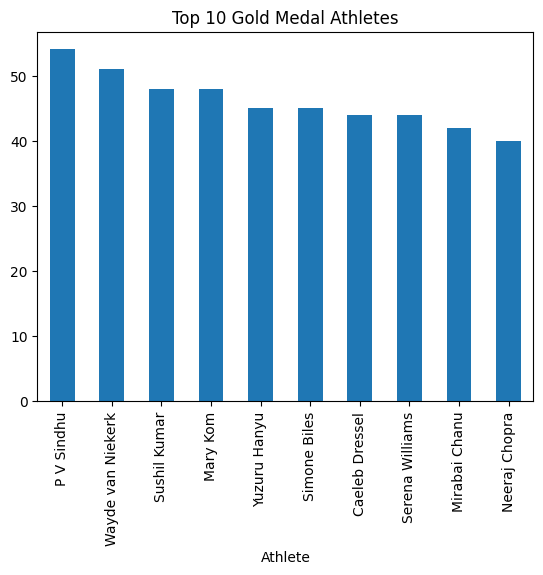

In [80]:
df[df['Medal']=='Gold']['Athlete'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Gold Medal Athletes")
plt.show()

In [83]:
import mysql.connector
import pandas as pd

config = {
    'host': '127.0.0.1',
    'user': 'root',
    'password': 'password',
    'database': 'Olympic_Games'
}

try:
    conn = mysql.connector.connect(**config)
    print("Connection successful!")

    # Test query: List all tables first
    df_tables = pd.read_sql_query("SHOW TABLES;", conn)
    print("Tables in database:")
    print(df_tables)

    # Replace 'your_table' with actual table, e.g., first table name
    # df = pd.read_sql_query("SELECT * FROM actual_table_name LIMIT 5", conn)
    # print(df)

except mysql.connector.Error as err:
    print(f"Error: {err}")
finally:
    if 'conn' in locals() and conn.is_connected():
        conn.close()


Connection successful!
Tables in database:
Empty DataFrame
Columns: [Tables_in_olympic_games]
Index: []


C:\Users\Test\AppData\Local\Temp\ipykernel_18552\3363045832.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_tables = pd.read_sql_query("SHOW TABLES;", conn)


In [82]:
# Create database if it doesn't exist
import mysql.connector

config = {
    'host': '127.0.0.1',
    'user': 'root',
    'password': 'password'
}

try:
    conn = mysql.connector.connect(**config)
    cursor = conn.cursor()
    cursor.execute("CREATE DATABASE IF NOT EXISTS Olympic_Games")
    conn.commit()
    print("Database 'Olympic_Games' created successfully or already exists!")
    conn.close()
except mysql.connector.Error as err:
    print(f"Error creating database: {err}")


Database 'Olympic_Games' created successfully or already exists!


In [84]:
from sqlalchemy import create_engine

# MySQL connection
username = "root"
password = "password"
host = "localhost"
port = "3306"
database = "Olympic_Games"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "olympic"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

# Read back sample
pd.read_sql("SELECT * FROM olympic LIMIT 5;", engine)

,Year,Season,City,Sport,Event,Athlete,Gender,Country,Medal,Age
0,2008,Summer,London,Badminton,Event_4,Caeleb Dressel,Male,Jamaica,Silver,20
1,2020,Summer,Rio,Gymnastics,Event_20,Sushil Kumar,Female,USA,Gold,24
2,2020,Summer,Rio,Swimming,Event_8,Mary Kom,Female,Australia,Gold,35
3,2020,Summer,London,Swimming,Event_10,Yuzuru Hanyu,Female,Australia,Gold,32
4,2008,Summer,Tokyo,Wrestling,Event_11,Caeleb Dressel,Female,Jamaica,Silver,22
